In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [242]:
#df = pd.read_csv("../data/antoine/radar24/test4.csv")
df = pd.read_csv("../data/kelly/X_vitesse.csv")
X_time = df["Time_s"].values
X_velocity = df["Vmax_m_s"].values
X0 = -5
X_position = cumulative_trapezoid(X_velocity, X_time, initial=0)


#df = pd.read_csv("../data/antoine/radar9/test4.csv")
df = pd.read_csv("../data/kelly/Y_vitesse.csv")
Y_time = df["Time_s"].values
Y_velocity = df["Vmax_m_s"].values
Y0 = 25
Y_position = cumulative_trapezoid(Y_velocity, Y_time, initial=0)

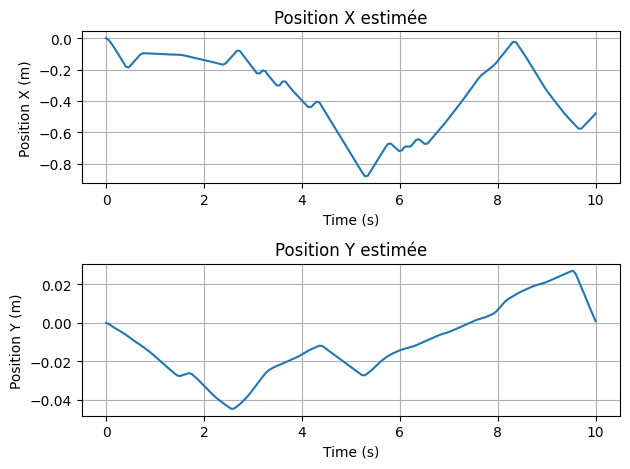

In [243]:

plt.figure()

# Plot X
plt.subplot(2, 1, 1)
plt.plot(X_time, X_position)
plt.xlabel("Time (s)")
plt.ylabel("Position X (m)")
plt.title("Position X estimée")
plt.grid()

# Plot Y
plt.subplot(2, 1, 2)
plt.plot(Y_time, Y_position)
plt.xlabel("Time (s)")
plt.ylabel("Position Y (m)")
plt.title("Position Y estimée")
plt.grid()

plt.tight_layout()
plt.show()


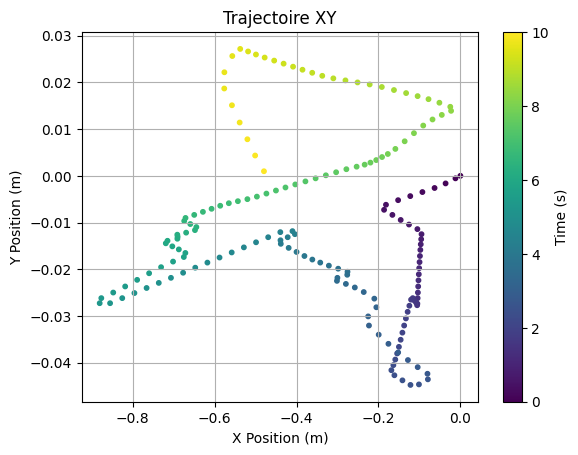

In [244]:

plt.figure()
sc = plt.scatter(X_position, Y_position, c=X_time, cmap='viridis', s=10)
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [245]:
x = X_position - np.mean(X_position)
y = Y_position - np.mean(Y_position)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

In [246]:
mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

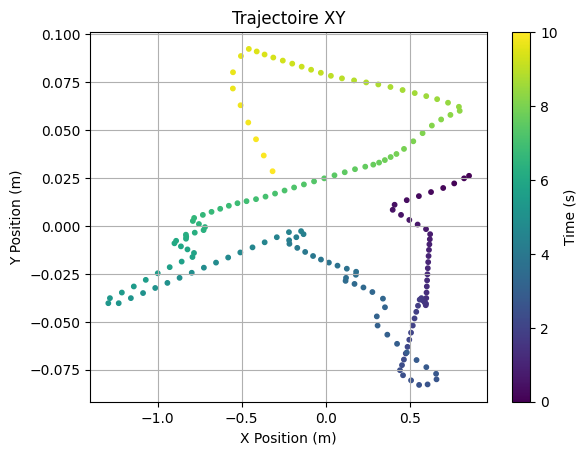

In [ ]:

plt.figure()
sc = plt.scatter(x_norm, y_norm, c=X_time, cmap='viridis', s=10)
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [248]:
print("X mean:", np.mean(X_position))
print("Y mean:", np.mean(Y_position))

X mean: -0.3496642483868801
Y mean: -0.010731691109480372
